In [67]:
import numpy as np
import pandas as pd
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


## Load Data

In [33]:
strava_gwr_features = gpd.read_file("Data/GWR_Features/strava_gwr_features.gpkg").to_crs(epsg=2193)

In [34]:
strava_gwr_features.columns

Index(['edgeUID', 'source', 'total_trip_count', 'elevation_range',
       'elevation_max', 'gradient', 'id', 'highway', 'road',
       'Rural_settlement_distances', 'Small_urban_distances',
       'Medium_urban_distances', 'Major_urban_distances', 'trail_density_400m',
       'trail_density_600m', 'trail_density_800m', 'trail_density_1000m',
       'Artificial_proportion', 'Forest_proportion', 'Grassland_proportion',
       'Scrubland_proportion', 'Water_Bodies_proportion', 'degree_centrality',
       'closeness_centrality', 'toilets_distance', 'hut_distance',
       'eateries_distance', 'parking_distance', 'distance_to_road',
       'geometry'],
      dtype='object')

In [35]:
feature_dict = {
    'bike': strava_gwr_features[strava_gwr_features['source'] == 'bike'],
    'ped': strava_gwr_features[strava_gwr_features['source'] == 'ped']
}

In [45]:
for name, df in feature_dict.items():
    df = df[~df['road']]
    df = df.drop(columns=['edgeUID','source','road','highway','id'])
    df.rename(columns={'total_trip_count': 'count'}, inplace=True)
    df.drop
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    feature_dict[name] = df
    df.to_file(f"Data/GWR_Analysis_Files/features.gpkg", layer = name, driver="GPKG")


# Prechecks

## Collinearity

In [46]:
feature_dict ={"ped": gpd.read_file("Data/GWR_Analysis_Files/features.gpkg", layer="ped").to_crs(epsg=2193),
                "bike": gpd.read_file("Data/GWR_Analysis_Files/features.gpkg", layer="bike").to_crs(epsg=2193)}

In [54]:

def check_multicollinearity(df, feature_cols, vif_threshold=7.5):
    """
    Performs correlation and VIF checks on candidate independent variables for GWR.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the dataset.
    feature_cols : list of str
        List of predictor variable column names.
    vif_threshold : float
        Threshold for flagging high VIF values (typically 5 to 10 for GWR).
        
    Returns:
    --------
    vif_df : pandas.DataFrame
        DataFrame containing features and their corresponding VIF scores.
    """
    # Select feature subset and drop missing values
    X = df[feature_cols].copy().dropna()

    """
    Robust VIF check handling NaNs, Infs, non-numeric types, and constant columns.
    """
    # 1. Select numeric features & drop missing / infinite values
    X = df[feature_cols].copy()
    X = X.select_dtypes(include=[np.number])  # Remove non-numeric columns if accidentally passed
    X = X.replace([np.inf, -np.inf], np.nan).dropna()
    
    # Check if we have valid rows left
    if X.empty:
        raise ValueError("DataFrame is empty after dropping NaN/Inf values! Check your features.")
    
    # 2. Check for constant columns (zero variance breaks VIF math)
    constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
    if constant_cols:
        print(f"⚠️ Warning: Dropping zero-variance feature(s): {constant_cols}")
        X = X.drop(columns=constant_cols)
    # -------------------------------------------------------------
    # 1. Pairwise Correlation Heatmap
    # -------------------------------------------------------------
    corr_matrix = X.corr()
    
    plt.figure(figsize=(15, 15))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Predictor Correlation Heatmap", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    # -------------------------------------------------------------
    # 2. Variance Inflation Factor (VIF)
    # -------------------------------------------------------------
    # Add constant term (intercept) required for accurate VIF calculation
    X_with_const = add_constant(X)
    
    vif_data = []
    for i, col in enumerate(X_with_const.columns):
        if col == "const":
            continue  # Skip intercept term in the final summary
            
        vif_val = variance_inflation_factor(X_with_const.values, i)
        vif_data.append({
            "Variable": col,
            "VIF": round(vif_val, 2),
            "Status": "High Collinearity" if vif_val >= vif_threshold else "OK"
        })
        
    vif_df = pd.DataFrame(vif_data).sort_values(by="VIF", ascending=False)
    
    print("\n================ VIF RESULTS ================")
    print(vif_df.to_string(index=False))
    print("=============================================\n")
    
    return vif_df

Checking multicollinearity for ped features...


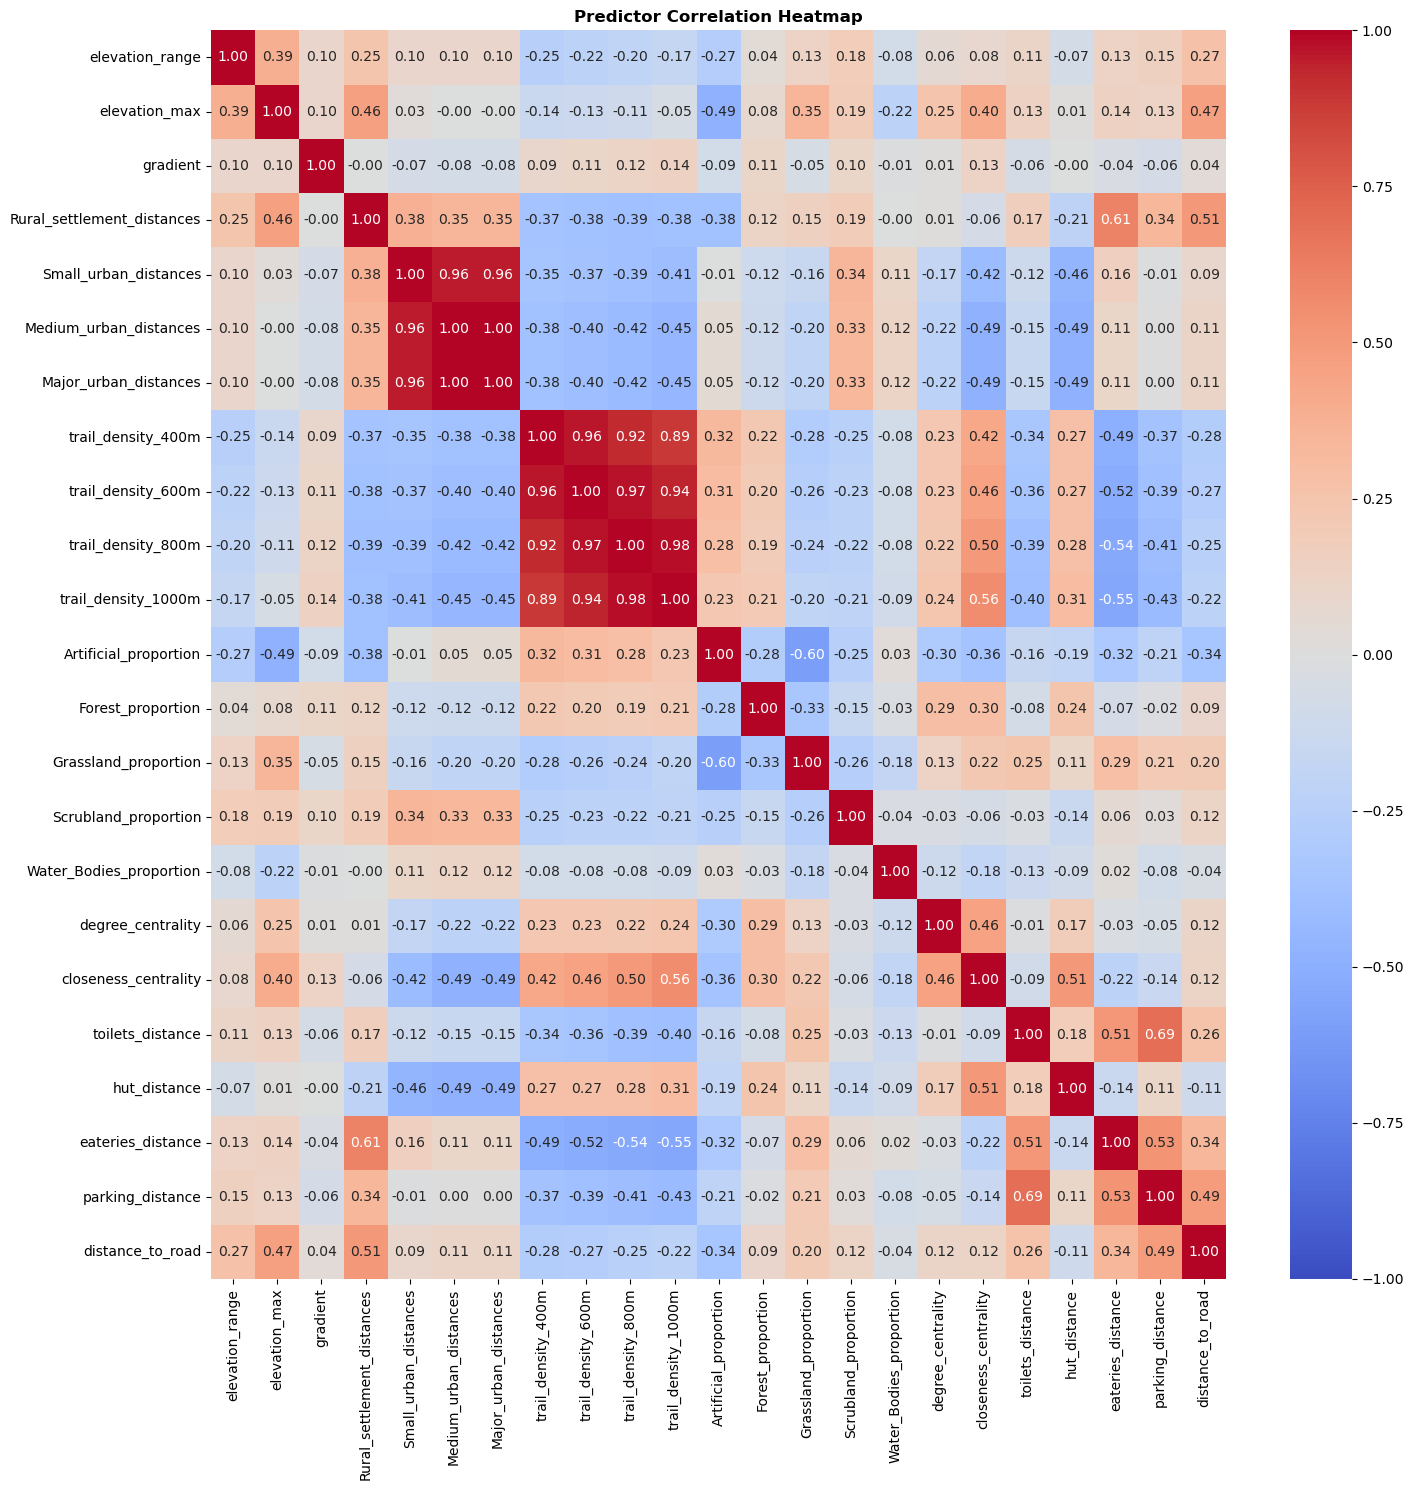

c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



================ VIF RESULTS ================
                  Variable   VIF            Status
     Major_urban_distances   inf High Collinearity
    Medium_urban_distances   inf High Collinearity
        trail_density_800m 70.32 High Collinearity
      Grassland_proportion 57.41 High Collinearity
     Artificial_proportion 52.43 High Collinearity
        trail_density_600m 46.71 High Collinearity
       trail_density_1000m 36.06 High Collinearity
         Forest_proportion 28.56 High Collinearity
      Scrubland_proportion 22.87 High Collinearity
        trail_density_400m 15.80 High Collinearity
     Small_urban_distances 14.85 High Collinearity
      closeness_centrality  3.53                OK
         eateries_distance  3.12                OK
   Water_Bodies_proportion  3.10                OK
Rural_settlement_distances  3.04                OK
          parking_distance  2.83                OK
          toilets_distance  2.64                OK
             elevation_max  2.46   

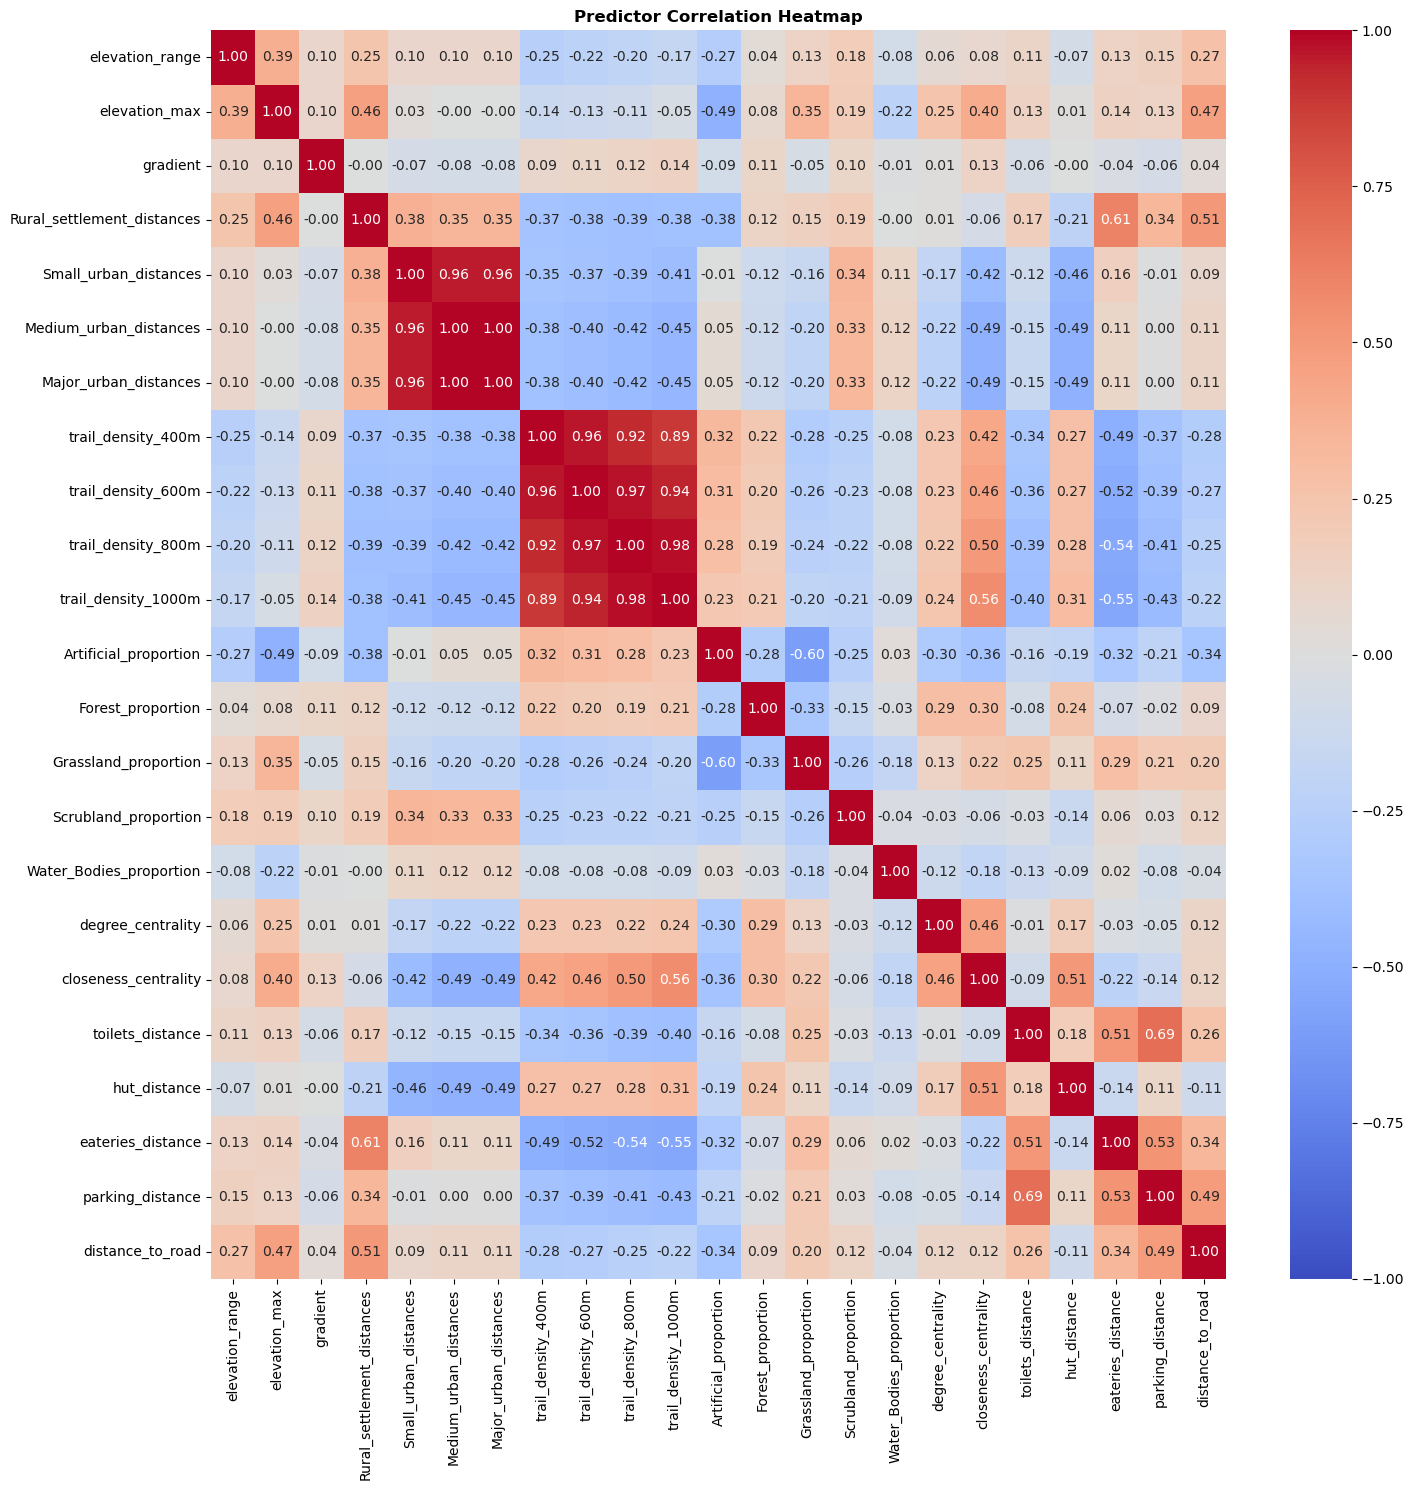


================ VIF RESULTS ================
                  Variable   VIF            Status
     Major_urban_distances   inf High Collinearity
    Medium_urban_distances   inf High Collinearity
        trail_density_800m 70.32 High Collinearity
      Grassland_proportion 57.41 High Collinearity
     Artificial_proportion 52.43 High Collinearity
        trail_density_600m 46.71 High Collinearity
       trail_density_1000m 36.06 High Collinearity
         Forest_proportion 28.56 High Collinearity
      Scrubland_proportion 22.87 High Collinearity
        trail_density_400m 15.80 High Collinearity
     Small_urban_distances 14.85 High Collinearity
      closeness_centrality  3.53                OK
         eateries_distance  3.12                OK
   Water_Bodies_proportion  3.10                OK
Rural_settlement_distances  3.04                OK
          parking_distance  2.83                OK
          toilets_distance  2.64                OK
             elevation_max  2.46   

c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [55]:
vif = {}
for name, df in feature_dict.items():
    feature_df = df.drop(columns=['count']).copy()
    
    print(f"Checking multicollinearity for {name} features...")
    vif[name] = check_multicollinearity(feature_df, feature_df.columns.tolist(), vif_threshold=7.5)

Checking multicollinearity for ped features...


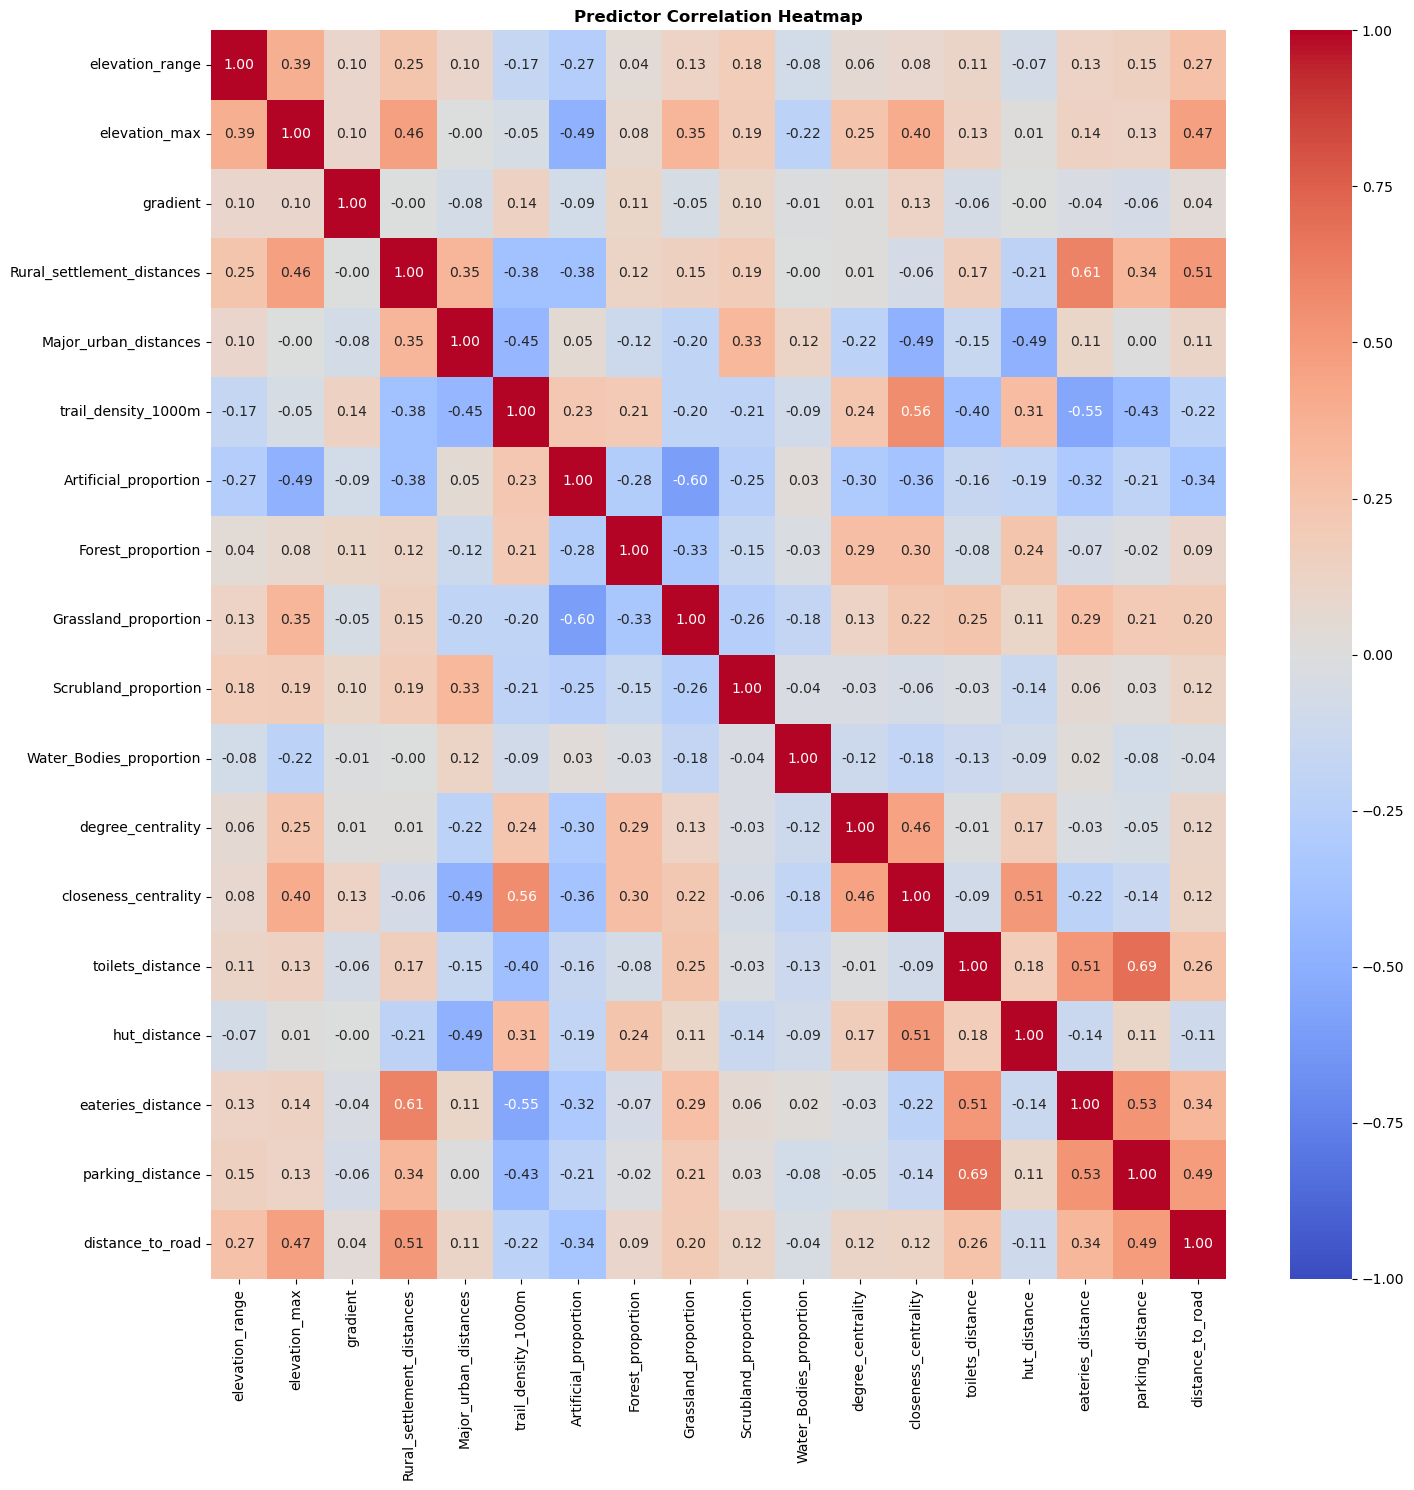


================ VIF RESULTS ================
                  Variable   VIF            Status
      Grassland_proportion 56.73 High Collinearity
     Artificial_proportion 51.26 High Collinearity
         Forest_proportion 28.08 High Collinearity
      Scrubland_proportion 22.65 High Collinearity
      closeness_centrality  3.46                OK
       trail_density_1000m  3.10                OK
   Water_Bodies_proportion  3.08                OK
Rural_settlement_distances  3.02                OK
         eateries_distance  3.01                OK
          parking_distance  2.76                OK
          toilets_distance  2.57                OK
             elevation_max  2.42                OK
     Major_urban_distances  2.15                OK
          distance_to_road  1.97                OK
              hut_distance  1.94                OK
         degree_centrality  1.40                OK
           elevation_range  1.25                OK
                  gradient  1.09   

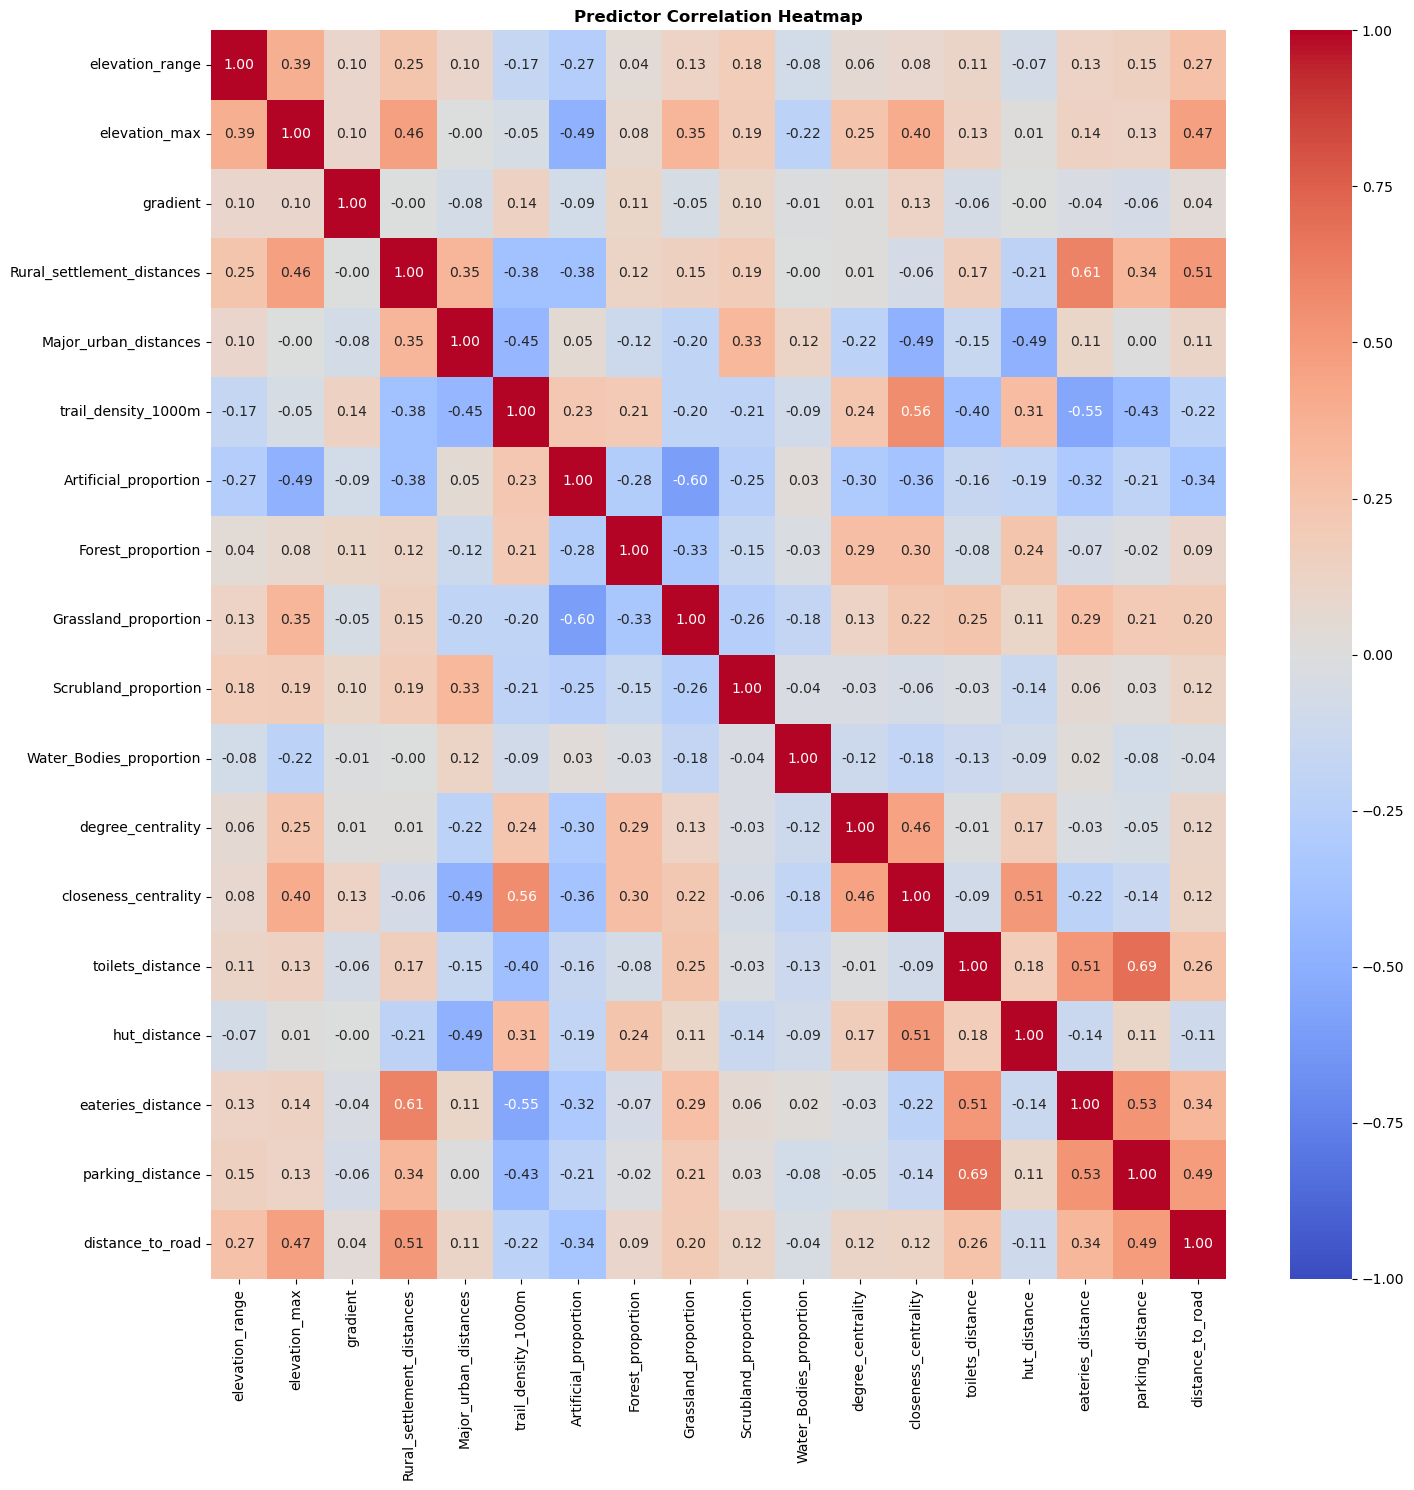


================ VIF RESULTS ================
                  Variable   VIF            Status
      Grassland_proportion 56.73 High Collinearity
     Artificial_proportion 51.26 High Collinearity
         Forest_proportion 28.08 High Collinearity
      Scrubland_proportion 22.65 High Collinearity
      closeness_centrality  3.46                OK
       trail_density_1000m  3.10                OK
   Water_Bodies_proportion  3.08                OK
Rural_settlement_distances  3.02                OK
         eateries_distance  3.01                OK
          parking_distance  2.76                OK
          toilets_distance  2.57                OK
             elevation_max  2.42                OK
     Major_urban_distances  2.15                OK
          distance_to_road  1.97                OK
              hut_distance  1.94                OK
         degree_centrality  1.40                OK
           elevation_range  1.25                OK
                  gradient  1.09   

In [56]:
vif = {}
for name, df in feature_dict.items():
    feature_df = df.drop(columns=['count','Medium_urban_distances','Small_urban_distances','trail_density_400m','trail_density_600m','trail_density_800m'  ]).copy()
    
    print(f"Checking multicollinearity for {name} features...")
    vif[name] = check_multicollinearity(feature_df, feature_df.columns.tolist(), vif_threshold=7.5)

# OLS

In [68]:
ols_results = {}
for name, df in feature_dict.items():
    feature_df = df.drop(columns=['geometry','count']).copy()
    ols_results[name] = OLS(df['count'], add_constant(feature_df)).fit()
    print(f"Checking multicollinearity for {name} features...")
    

Checking multicollinearity for ped features...
Checking multicollinearity for bike features...


In [72]:
ols_results['ped'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  count   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     29.83
Date:                Wed, 22 Jul 2026   Prob (F-statistic):          1.04e-116
Time:                        23:05:49   Log-Likelihood:                -46653.
No. Observations:                5130   AIC:                         9.335e+04
Df Residuals:                    5107   BIC:                         9.350e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                       1028.5128    566.169      1.817      0.069     -81.421    2138.447
elevation_range               -2.2420      1.350     -1.661      0.097      -4.889       0.405
elevation_max                 -0.2437      0.273     -0.894      0.371      -0.778       0.291
gradient                    -738.2555    231.549     -3.188      0.001   -1192.191    -284.320
Rural_settlement_distances    -0.0919      0.020     -4.675      0.000      -0.130      -0.053
Small_urban_distances          0.0218      0.009      2.510      0.012       0.005       0.039
Medium_urban_distances        -0.0111      0.003     -3.453      0.001      -0.017      -0.005
Major_urban_distances         -0.0111      0.003     -3.460      0.001      -0.017      -0.005
trail_density_400m         -2842.8736   6457.803     -0.440      0.660   -1.55e+04    9817.187
trail_density_600m         -1.378e+04   1.47e+04     -0.935      0.350   -4.27e+04    1.51e+04
trail_density_800m         -3.442e+04   2.27e+04     -1.514      0.130    -7.9e+04    1.01e+04
trail_density_1000m         5.864e+04   1.91e+04      3.075      0.002    2.13e+04     9.6e+04
Artificial_proportion       -427.4462    537.312     -0.796      0.426   -1480.808     625.916
Forest_proportion           -200.4287    542.042     -0.370      0.712   -1263.063     862.206
Grassland_proportion         427.2449    532.067      0.803      0.422    -615.835    1470.325
Scrubland_proportion        -300.6265    538.812     -0.558      0.577   -1356.928     755.675
Water_Bodies_proportion      600.5000    635.233      0.945      0.345    -644.829    1845.829
degree_centrality          -8.232e+05   6.02e+05     -1.368      0.171      -2e+06    3.57e+05
closeness_centrality         3.98e+05   4.07e+04      9.779      0.000    3.18e+05    4.78e+05
toilets_distance              -0.0718      0.025     -2.923      0.003      -0.120      -0.024
hut_distance                  -0.0290      0.007     -3.884      0.000      -0.044      -0.014
eateries_distance              0.1042      0.017      6.146      0.000       0.071       0.137
parking_distance              -0.0156      0.032     -0.492      0.623      -0.078       0.047
distance_to_road              -0.1456      0.064     -2.283      0.022      -0.271      -0.021
==============================================================================
Omnibus:                     5870.469   Durbin-Watson:                   1.804
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           613036.536
Skew:                           5.952   Prob(JB):                         0.00
Kurtosis:                      55.214   Cond. No.                     2.39e+17
==============================================================================

Notes:
[1] Standard Errors assume that the 